In [1]:
!pip install -q gdown torch torchvision facenet-pytorch opencv-python-headless kagglehub kornia onnx onnxscript


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.2 MB/s eta 0:00:00


In [13]:
from google.colab import drive
import zipfile
drive.mount('/content/drive')

with zipfile.ZipFile('/content/drive/MyDrive/glasses_aligned_faces.zip', 'r') as z:
    z.extractall('/content/glasses_aligned_faces')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import shutil
from pathlib import Path

misplaced_root_dir = Path("/content/glasses_aligned_faces/content/glasses_aligned_faces")
correct_target_dir = Path("/content/glasses_aligned_face")

if misplaced_root_dir.exists():
    if correct_target_dir.exists():
        shutil.rmtree(correct_target_dir)
    shutil.move(str(misplaced_root_dir), str(correct_target_dir))
    print("Successfully moved directory")
else:
    print("Directory already in correct location")


Successfully moved directory


In [15]:
import os
from pathlib import Path

no_glasses_dir = Path('/content/glasses_aligned_faces/no_glasses')
all_imgs = sorted([p for p in no_glasses_dir.glob('*')
                   if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])

print(f"no_glasses before: {len(all_imgs)}")
for p in all_imgs[14000:]:
    p.unlink()

remaining = len(list(no_glasses_dir.glob('*.jpg')))
print(f"no_glasses after:  {remaining}")

# Verify all classes
ALIGNED_DIR = '/content/glasses_aligned_faces'
for cls in ['no_glasses', 'eyeglasses', 'sunglasses']:
    count = len(list(Path(ALIGNED_DIR, cls).glob('*')))
    print(f"  {cls}: {count}")


no_glasses before: 17000
no_glasses after:  14000
  no_glasses: 14000
  eyeglasses: 6600
  sunglasses: 5500


In [7]:
import os, shutil, warnings, time, collections
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
import kornia.augmentation as K
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

ALIGNED_DIR = '/content/glasses_aligned_faces'
IMG_SIZE    = (224, 224)
IMAGE_EXTS  = {'.jpg', '.jpeg', '.png'}


Device: cuda


In [8]:
def build_cache(aligned_dir, class_names, label_map, cache_prefix, split_ratios=(0.80, 0.10, 0.10), img_size=(224, 224)):
    """
    Reads directly from aligned_dir/class_name, applies label_map,
    splits into train/val/test, and saves .npy caches.
    Returns (train_imgs, train_lbls, val_imgs, val_lbls, test_imgs, test_lbls)
    """
    cache_files = {
        split: (f'/content/{cache_prefix}_{split}_imgs.npy',
                f'/content/{cache_prefix}_{split}_lbls.npy')
        for split in ['train', 'val', 'test']
    }

    # Load from cache if all files exist
    if all(os.path.exists(p) for paths in cache_files.values() for p in paths):
        print(f"Cache found for '{cache_prefix}', loading...")
        results = []
        for split in ['train', 'val', 'test']:
            ci, cl = cache_files[split]
            results += [np.load(ci, mmap_mode='r'), np.load(cl)]
        return results

    print(f"Building cache for '{cache_prefix}'...")

    # Collect all samples
    all_samples = []
    for cls in class_names:
        cls_dir = Path(aligned_dir) / cls
        if not cls_dir.exists():
            print(f"  WARNING: {cls_dir} not found, skipping")
            continue
        label = label_map[cls]
        for f in cls_dir.glob('*'):
            if f.suffix.lower() in IMAGE_EXTS:
                all_samples.append((str(f), label))

    np.random.shuffle(all_samples)
    n = len(all_samples)
    tr = int(n * split_ratios[0])
    vl = int(n * split_ratios[1])

    splits = {
        'train': all_samples[:tr],
        'val':   all_samples[tr:tr+vl],
        'test':  all_samples[tr+vl:],
    }

    results = []
    for split, samples in splits.items():
        imgs = np.zeros((len(samples), img_size[0], img_size[1], 3), dtype=np.uint8)
        lbls = np.zeros(len(samples), dtype=np.int64)
        for i, (path, label) in enumerate(samples):
            img = cv2.imread(path)
            imgs[i] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            lbls[i] = label
            if i % 1000 == 0:
                print(f"  {split} {i}/{len(samples)}")
        ci, cl = cache_files[split]
        np.save(ci, imgs)
        np.save(cl, lbls)
        results += [np.load(ci, mmap_mode='r'), lbls]
        print(f"  {split}: {len(samples)} samples, "
              f"label dist: {dict(collections.Counter(lbls.tolist()))}")

    return results


class CachedDataset(Dataset):
    def __init__(self, imgs, lbls, transform=None):
        self.imgs      = imgs
        self.lbls      = lbls
        self.transform = transform

    def __len__(self):
        return len(self.lbls)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx].copy()).permute(2, 0, 1).float().div(255)
        if self.transform:
            img = self.transform(img)
        return img, int(self.lbls[idx])


def make_loaders(train_imgs, train_lbls, val_imgs, val_lbls,
                 test_imgs, test_lbls, val_norm, batch_size=128):
    train_ds = CachedDataset(train_imgs, train_lbls, transform=None)
    val_ds   = CachedDataset(val_imgs,   val_lbls,   transform=val_norm)
    test_ds  = CachedDataset(test_imgs,  test_lbls,  transform=val_norm)
    kw = dict(num_workers=4, pin_memory=True, persistent_workers=True)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
        train_ds, val_ds, test_ds,
    )

val_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
print("Dataset utils ready.")


Dataset utils ready.


In [9]:
def make_model(num_classes, device):
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Linear(576, 1024),
        nn.Hardswish(),
        nn.Dropout(0.5),
        nn.Linear(1024, num_classes),
    )
    model = model.to(device)
    try:
        model = torch.compile(model, mode='reduce-overhead')
        print("torch.compile enabled")
    except Exception as e:
        print(f"torch.compile unavailable: {e}")
    return model


def train_epoch(model, loader, optimizer, criterion, train_aug, device, scaler):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.no_grad():
            x = train_aug(x)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            out  = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                out  = model(x)
                loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer,
                train_aug, device, save_path, epochs=30,
                lr_patience=5, stop_patience=15):
    scaler  = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion,
                                      train_aug, device, scaler)
        vl_loss, vl_acc = validate_epoch(model, val_loader, criterion, device)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"Epoch {epoch+1}/{epochs} ({elapsed:.1f}s)  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve % lr_patience == 0:
                for pg in optimizer.param_groups:
                    pg['lr'] *= 0.2
                print(f"  LR reduced -> {optimizer.param_groups[0]['lr']:.2e}")
            if no_improve >= stop_patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def fine_tune(model, train_loader, val_loader, criterion,
              train_aug, device, save_path, epochs=15, lr=1e-4):
    # Freeze all, unfreeze last 5 feature layers + classifier
    for param in model.parameters():
        param.requires_grad = False
    try:
        backbone = model._orig_mod
    except AttributeError:
        backbone = model
    for layer in list(backbone.features.children())[-5:]:
        for param in layer.parameters():
            param.requires_grad = True
    for param in backbone.classifier.parameters():
        param.requires_grad = True

    optimizer_ft = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    return train_model(model, train_loader, val_loader, criterion, optimizer_ft,
                       train_aug, device, save_path, epochs=epochs,
                       lr_patience=5, stop_patience=10)


def evaluate(model, test_loader, criterion, class_names, device):
    test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print(classification_report(all_labels, all_preds, target_names=class_names))


def plot_history(*histories):
    combined = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for h in histories:
        for k in combined:
            combined[k].extend(h[k])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(combined['train_acc'], label='Train')
    ax1.plot(combined['val_acc'],   label='Val')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)
    ax2.plot(combined['train_loss'], label='Train')
    ax2.plot(combined['val_loss'],   label='Val')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()


def export_onnx(model, save_path, device):
    try:
        m = model._orig_mod
    except AttributeError:
        m = model
    m.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    torch.onnx.export(
        m, dummy, save_path,
        export_params=True, opset_version=11, do_constant_folding=True,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    )
    print(f"Saved {save_path}")

print("Training utils ready.")


Training utils ready.


## Stage 1 — Glasses vs No Glasses

In [19]:
# no_glasses=0, sunglasses=1, eyeglasses=1
S1_LABEL_MAP  = {'no_glasses': 0, 'sunglasses': 1, 'eyeglasses': 1}
S1_CLASS_NAMES = ['no_glasses', 'glasses']

train_aug_s1 = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.ColorJitter(brightness=0.2, contrast=0.2),
    K.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

s1_data = build_cache(
    ALIGNED_DIR,
    class_names=['no_glasses', 'sunglasses', 'eyeglasses'],
    label_map=S1_LABEL_MAP,
    cache_prefix='s1',
)
s1_train_loader, s1_val_loader, s1_test_loader, *_ = make_loaders(*s1_data, val_norm)
print("Stage 1 loaders ready.")


Building cache for 's1'...
  train 0/20880
  train 1000/20880
  train 2000/20880
  train 3000/20880
  train 4000/20880
  train 5000/20880
  train 6000/20880
  train 7000/20880
  train 8000/20880
  train 9000/20880
  train 10000/20880
  train 11000/20880
  train 12000/20880
  train 13000/20880
  train 14000/20880
  train 15000/20880
  train 16000/20880
  train 17000/20880
  train 18000/20880
  train 19000/20880
  train 20000/20880
  train: 20880 samples, label dist: {0: 11240, 1: 9640}
  val 0/2610
  val 1000/2610
  val 2000/2610
  val: 2610 samples, label dist: {0: 1358, 1: 1252}
  test 0/2610
  test 1000/2610
  test 2000/2610
  test: 2610 samples, label dist: {0: 1402, 1: 1208}
Stage 1 loaders ready.


In [20]:
s1_model     = make_model(num_classes=2, device=device)
s1_criterion = nn.CrossEntropyLoss()
s1_optimizer = optim.Adam(s1_model.parameters(), lr=1e-3)

s1_model, s1_hist_p1 = train_model(
    s1_model, s1_train_loader, s1_val_loader,
    s1_criterion, s1_optimizer, train_aug_s1,
    device, save_path='s1_best.pth', epochs=30,
)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 133MB/s]


torch.compile enabled


W0620 04:26:44.342000 3013 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/30 (295.8s)  tr_loss=0.4083  tr_acc=0.7414  vl_loss=0.4288  vl_acc=0.7322
Epoch 2/30 (45.2s)  tr_loss=0.3794  tr_acc=0.7575  vl_loss=0.4074  vl_acc=0.7360
Epoch 3/30 (31.5s)  tr_loss=0.3661  tr_acc=0.7543  vl_loss=0.4060  vl_acc=0.7448
Epoch 4/30 (30.0s)  tr_loss=0.3628  tr_acc=0.7558  vl_loss=0.4327  vl_acc=0.7391
Epoch 5/30 (29.9s)  tr_loss=0.3598  tr_acc=0.7594  vl_loss=0.4003  vl_acc=0.7360
Epoch 6/30 (30.3s)  tr_loss=0.3559  tr_acc=0.7600  vl_loss=0.3945  vl_acc=0.7398
Epoch 7/30 (30.2s)  tr_loss=0.3508  tr_acc=0.7640  vl_loss=0.4184  vl_acc=0.7502
Epoch 8/30 (27.6s)  tr_loss=0.3542  tr_acc=0.7622  vl_loss=0.4090  vl_acc=0.7456
Epoch 9/30 (28.4s)  tr_loss=0.3480  tr_acc=0.7635  vl_loss=0.4130  vl_acc=0.7548
Epoch 10/30 (28.0s)  tr_loss=0.3492  tr_acc=0.7609  vl_loss=0.4260  vl_acc=0.7107
Epoch 11/30 (29.5s)  tr_loss=0.3451  tr_acc=0.7647  vl_loss=0.5257  vl_acc=0.7406
Epoch 12/30 (29.2s)  tr_loss=0.3457  tr_acc=0.7636  vl_loss=0.4130  vl_acc=0.7184
Epoch 13/30 (28.8s)  tr_

In [21]:
s1_model, s1_hist_p2 = fine_tune(
    s1_model, s1_train_loader, s1_val_loader,
    s1_criterion, train_aug_s1, device,
    save_path='s1_best.pth', epochs=15, lr=1e-4,
)


Epoch 1/15 (24.4s)  tr_loss=0.3393  tr_acc=0.7694  vl_loss=0.4281  vl_acc=0.7115
Epoch 2/15 (24.8s)  tr_loss=0.3356  tr_acc=0.7712  vl_loss=0.4288  vl_acc=0.7038
Epoch 3/15 (23.5s)  tr_loss=0.3345  tr_acc=0.7758  vl_loss=0.4427  vl_acc=0.7061
Epoch 4/15 (25.9s)  tr_loss=0.3330  tr_acc=0.7760  vl_loss=0.4570  vl_acc=0.6920
Epoch 5/15 (30.5s)  tr_loss=0.3329  tr_acc=0.7781  vl_loss=0.4532  vl_acc=0.6897
Epoch 6/15 (24.6s)  tr_loss=0.3311  tr_acc=0.7796  vl_loss=0.4702  vl_acc=0.6866
  LR reduced -> 2.00e-05
Epoch 7/15 (23.5s)  tr_loss=0.3306  tr_acc=0.7827  vl_loss=0.4723  vl_acc=0.6851
Epoch 8/15 (25.2s)  tr_loss=0.3298  tr_acc=0.7841  vl_loss=0.4771  vl_acc=0.6828
Epoch 9/15 (26.2s)  tr_loss=0.3300  tr_acc=0.7808  vl_loss=0.4763  vl_acc=0.6839
Epoch 10/15 (24.9s)  tr_loss=0.3295  tr_acc=0.7814  vl_loss=0.4797  vl_acc=0.6824
Epoch 11/15 (25.2s)  tr_loss=0.3302  tr_acc=0.7830  vl_loss=0.4800  vl_acc=0.6789
  LR reduced -> 4.00e-06
Early stopping.


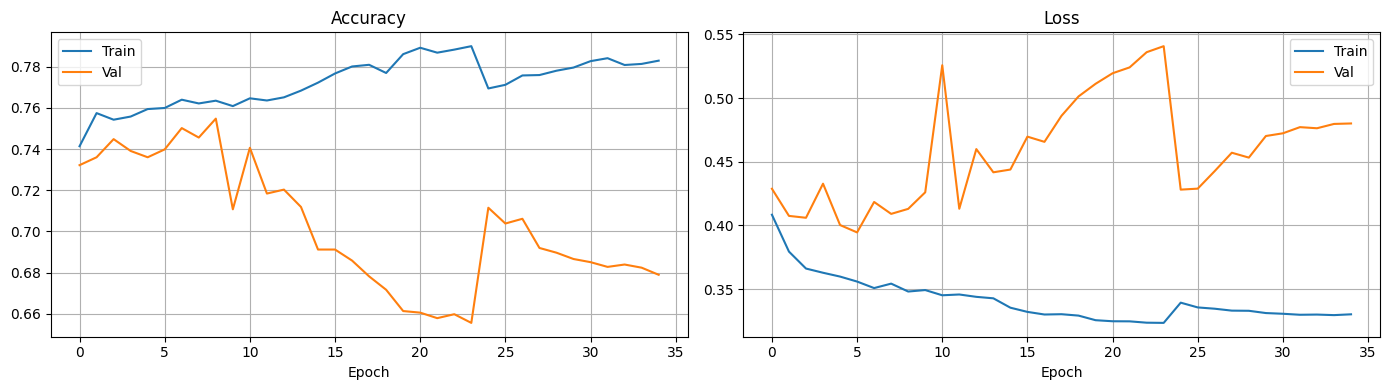

Test Loss: 0.4251   Test Accuracy: 0.7184


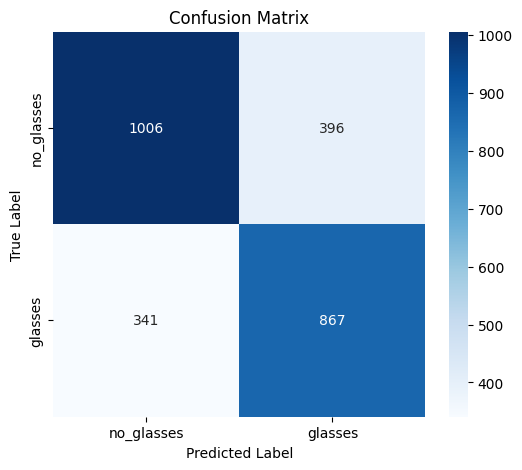

              precision    recall  f1-score   support

  no_glasses       0.75      0.72      0.73      1402
     glasses       0.69      0.72      0.70      1208

    accuracy                           0.72      2610
   macro avg       0.72      0.72      0.72      2610
weighted avg       0.72      0.72      0.72      2610



W0620 04:51:36.479000 3013 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved glasses_binary.onnx


In [22]:
plot_history(s1_hist_p1, s1_hist_p2)
evaluate(s1_model, s1_test_loader, s1_criterion, S1_CLASS_NAMES, device)

torch.save(s1_model.state_dict(), 'glasses_binary.pth')
export_onnx(s1_model, 'glasses_binary.onnx', device)


## Stage 2 — Sunglasses vs Eyeglasses

In [10]:
# no_glasses excluded entirely — only sunglasses and eyeglasses
S2_LABEL_MAP   = {'sunglasses': 0, 'eyeglasses': 1}
S2_CLASS_NAMES = ['sunglasses', 'eyeglasses']

train_aug_s2 = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.ColorJitter(brightness=0.2, contrast=0.2),
    K.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

s2_data = build_cache(
    ALIGNED_DIR,
    class_names=['sunglasses', 'eyeglasses'],   # no_glasses not passed → skipped
    label_map=S2_LABEL_MAP,
    cache_prefix='s2',
)
s2_train_loader, s2_val_loader, s2_test_loader, *_ = make_loaders(*s2_data, val_norm)
print("Stage 2 loaders ready.")


Cache found for 's2', loading...
Stage 2 loaders ready.


In [11]:
s2_model     = make_model(num_classes=2, device=device)
s2_criterion = nn.CrossEntropyLoss()
s2_optimizer = optim.Adam(s2_model.parameters(), lr=1e-3)

s2_model, s2_hist_p1 = train_model(
    s2_model, s2_train_loader, s2_val_loader,
    s2_criterion, s2_optimizer, train_aug_s2,
    device, save_path='s2_best.pth', epochs=30,
)


torch.compile enabled
Epoch 1/30 (67.8s)  tr_loss=0.1508  tr_acc=0.9382  vl_loss=0.2103  vl_acc=0.9421
Epoch 2/30 (18.1s)  tr_loss=0.0645  tr_acc=0.9779  vl_loss=0.2354  vl_acc=0.9289
Epoch 3/30 (13.0s)  tr_loss=0.0469  tr_acc=0.9835  vl_loss=0.1251  vl_acc=0.9769
Epoch 4/30 (11.7s)  tr_loss=0.0426  tr_acc=0.9850  vl_loss=0.1043  vl_acc=0.9719
Epoch 5/30 (11.8s)  tr_loss=0.0254  tr_acc=0.9906  vl_loss=0.1725  vl_acc=0.9636
Epoch 6/30 (10.4s)  tr_loss=0.0276  tr_acc=0.9896  vl_loss=0.0993  vl_acc=0.9769
Epoch 7/30 (11.4s)  tr_loss=0.0162  tr_acc=0.9930  vl_loss=0.1101  vl_acc=0.9818
Epoch 8/30 (11.5s)  tr_loss=0.0162  tr_acc=0.9933  vl_loss=0.1243  vl_acc=0.9760
Epoch 9/30 (11.5s)  tr_loss=0.0182  tr_acc=0.9930  vl_loss=0.1758  vl_acc=0.9752
Epoch 10/30 (10.8s)  tr_loss=0.0108  tr_acc=0.9951  vl_loss=0.1483  vl_acc=0.9777
Epoch 11/30 (11.2s)  tr_loss=0.0130  tr_acc=0.9939  vl_loss=0.1718  vl_acc=0.9736
Epoch 12/30 (11.7s)  tr_loss=0.0180  tr_acc=0.9934  vl_loss=0.1351  vl_acc=0.9686
  L

In [12]:
s2_model, s2_hist_p2 = fine_tune(
    s2_model, s2_train_loader, s2_val_loader,
    s2_criterion, train_aug_s2, device,
    save_path='s2_best.pth', epochs=15, lr=1e-4,
)


Epoch 1/15 (11.5s)  tr_loss=0.0083  tr_acc=0.9960  vl_loss=0.1210  vl_acc=0.9826
Epoch 2/15 (11.3s)  tr_loss=0.0064  tr_acc=0.9971  vl_loss=0.1260  vl_acc=0.9826
Epoch 3/15 (10.7s)  tr_loss=0.0052  tr_acc=0.9966  vl_loss=0.1332  vl_acc=0.9826
Epoch 4/15 (11.0s)  tr_loss=0.0051  tr_acc=0.9973  vl_loss=0.1416  vl_acc=0.9826
Epoch 5/15 (11.5s)  tr_loss=0.0048  tr_acc=0.9971  vl_loss=0.1506  vl_acc=0.9826
Epoch 6/15 (11.4s)  tr_loss=0.0048  tr_acc=0.9966  vl_loss=0.1566  vl_acc=0.9810
  LR reduced -> 2.00e-05
Epoch 7/15 (10.8s)  tr_loss=0.0039  tr_acc=0.9977  vl_loss=0.1567  vl_acc=0.9826
Epoch 8/15 (10.9s)  tr_loss=0.0041  tr_acc=0.9981  vl_loss=0.1582  vl_acc=0.9826
Epoch 9/15 (11.6s)  tr_loss=0.0043  tr_acc=0.9971  vl_loss=0.1588  vl_acc=0.9826
Epoch 10/15 (11.3s)  tr_loss=0.0041  tr_acc=0.9975  vl_loss=0.1599  vl_acc=0.9818
Epoch 11/15 (10.5s)  tr_loss=0.0041  tr_acc=0.9972  vl_loss=0.1599  vl_acc=0.9826
  LR reduced -> 4.00e-06
Early stopping.


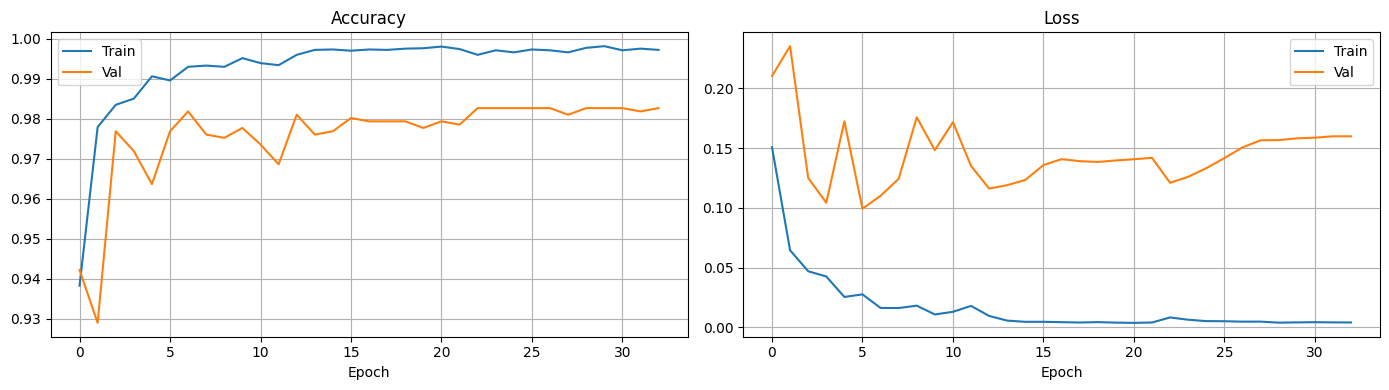

Test Loss: 0.0529   Test Accuracy: 0.9843


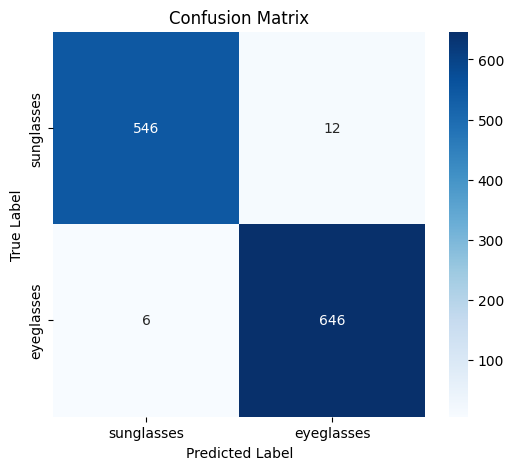

              precision    recall  f1-score   support

  sunglasses       0.99      0.98      0.98       558
  eyeglasses       0.98      0.99      0.99       652

    accuracy                           0.99      1210
   macro avg       0.99      0.98      0.99      1210
weighted avg       0.99      0.99      0.99      1210



W0620 05:28:47.574000 19755 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved glasses_type.onnx


In [13]:
plot_history(s2_hist_p1, s2_hist_p2)
evaluate(s2_model, s2_test_loader, s2_criterion, S2_CLASS_NAMES, device)

torch.save(s2_model.state_dict(), 'glasses_type.pth')
export_onnx(s2_model, 'glasses_type.onnx', device)
